# Experiment E - Temporal Window Sensitivity

## 1. Objective 

To investigate the sensitivity of football momentum forecasting performance to the temporal window size used during dataset construction by comparing 3-minute, 5-minute, and 10-minute prediction windows.

## 2. Hypothesis

The baseline 5-minute window provided strong predictive performance, but it is unclear whether this temporal resolution is optimal. Reducing the window size to 3 minutes may produce noisier momentum labels because fewer events contribute to each window, while increasing the window size to 10 minutes may smooth short-term momentum changes by aggregating more events. Consequently, the 5-minute window is expected to provide the best balance between capturing meaningful momentum shifts and reducing label noise. All other aspects of the dataset construction, momentum calculation, thresholds, and model architecture will remain unchanged so that any performance differences can be attributed solely to the choice of window size.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from config import *
from helper import *

#Paths
DATA_PATH = BASE_DIR / "data" / "processed" / EXPERIMENT
MODELS_PATH = BASE_DIR / 'models' / EXPERIMENT
REPORTS_PATH = BASE_DIR / 'reports' / 'metrics' / EXPERIMENT
FIGURE_PATH = BASE_DIR / "reports" / "figures" / EXPERIMENT

df = pd.read_csv("../data/raw/archive/events.csv")

## 3. Dataset Creation

The datasets were generated using the same preprocessing pipeline introduced in Experiment A, including the HOME_TEAM and AWAY_TEAM event prefixes. Two additional datasets were created using 3-minute and 10-minute windows while keeping the momentum weighting scheme, momentum thresholds, train/validation/test splits, and all other preprocessing steps identical to the baseline 5-minute configuration.

### 3.1 Loading Dataset

In [4]:
# Momentum weights
MOMENTUM_WEIGHTS = {
    1:  3, # Attempt
    2:  1, # Corner
    4: -1, # Yellow Card
    6: -3, # Red card
    9: -0.5 # Off-side
}


# Helper function
def get_event_weight(event):
    if event['event_type'] == 1 and event['is_goal'] == 1:
        return 5
    return MOMENTUM_WEIGHTS.get(event['event_type'], 0)


def calculate_momentum_label(match_df: pd.DataFrame, window_size: int=5):
    """
    Takes in a dataframe of match events & window size, returns a dataframe with momentum labels added

    Args:
        match_df (pd.DataFrame): Match events dataframe.
        window_size (int, optional): Rolling window of match time in minutes. Defaults to 5.
    """

    windows = []
    max_time = int(match_df['time'].max())

    for start in range(0, max_time, window_size):
        end = start + window_size 
        events = match_df[
            (match_df['time'] >= start) &
            (match_df['time'] < end)
        ]

        home_score = 0
        away_score = 0

        texts = []

        for _, event in events.iterrows():
            
            if pd.isna(event['text']):
                continue
            
            weight = get_event_weight(event)

            if event['side'] == 1:
                home_score += weight
            else:
                away_score += weight
            
            side = "HOME_TEAM" if event["side"] == 1 else "AWAY_TEAM"
            texts.append(f"[{side}] {event['text']}")

        momentum = home_score - away_score

        # Labeling momentum
        if momentum >= 2:
            label = 0 # Home Dominant
        elif momentum <= -2:
            label = 1
        else:
            label = 2 # Balanced

        combined_text = " ".join(texts)

        # Adding it to windows list
        windows.append({
            'id_odsp': match_df['id_odsp'].iloc[0],
            'window_start': start,
            'window_end': end,
            'momentum_score': momentum,
            'label': label,
            'text' : combined_text
        })
    
    # Return windows are a dataframe
    return pd.DataFrame(windows)

In [5]:
window_sizes = {3: "exp_e_window3", 10: "exp_e_window10"}

for ws, exp_name in window_sizes.items():
    all_windows = []

    for _, match_df in df.groupby("id_odsp", sort=False):
        all_windows.append(calculate_momentum_label(match_df, window_size=ws))

    experiment_df = pd.concat(all_windows, ignore_index=True)

    print(f"window_size={ws}")
    print(experiment_df["momentum_score"].describe())
    print(experiment_df["momentum_score"].value_counts().sort_index())
    print(experiment_df["label"].value_counts())
    print(experiment_df['label'].value_counts(normalize=True))

    experiment_df.to_csv(DATA_PATH / f"{exp_name}.csv", index=False)
    print(f"Saved {len(experiment_df)} windows to {DATA_PATH}")

window_size=3
count    274723.000000
mean          0.339748
std           3.509354
min         -27.000000
25%          -1.000000
50%           0.000000
75%           3.000000
max          27.000000
Name: momentum_score, dtype: float64
momentum_score
-27.0    1
-21.0    2
-19.0    6
-18.0    9
-17.5    2
        ..
 22.0    1
 23.0    1
 24.0    1
 25.0    1
 27.0    1
Name: count, Length: 84, dtype: int64
label
2    129874
0     81321
1     63528
Name: count, dtype: int64
label
2    0.472745
0    0.296011
1    0.231244
Name: proportion, dtype: float64
Saved 274723 windows to /Users/latasingh/Developer/PyTorch/football-momentum-forecasting/data/processed/exp_e_window_sens
window_size=10
count    83386.000000
mean         1.120824
std          6.763221
min        -34.000000
25%         -3.000000
50%          1.000000
75%          5.500000
max         41.000000
Name: momentum_score, dtype: float64
momentum_score
-34.0    1
-29.5    1
-29.0    2
-28.0    1
-27.0    2
        ..
 32.0    2


### 3.2 Dataset Validation

In [6]:
win3_df = pd.read_csv(DATA_PATH / 'exp_e_window3.csv')
win10_df = pd.read_csv(DATA_PATH / 'exp_e_window10.csv')

In [7]:
# Check Text null values
print(win3_df['text'].isna().sum())
print(win10_df['text'].isna().sum())

print((win3_df['text'] == '').sum())
print((win10_df['text'] == '').sum())

19973
22
0
0


In [8]:
win3_df = win3_df[win3_df['text'].notna()].reset_index(drop=True)
win10_df = win10_df[win10_df['text'].notna()].reset_index(drop=True)

print(f"win3 after filtering: {len(win3_df)}")
print(f"win10 after filtering: {len(win10_df)}")

win3 after filtering: 254750
win10 after filtering: 83364


In [9]:
# Unique id check
print(df['id_odsp'].nunique())
print(win10_df['id_odsp'].nunique())
print(win3_df['id_odsp'].nunique())


9074
9074
9074


In [10]:
# Check a sample of text from dfs
print(win3_df['text'].iloc[0])
print(win10_df['text'].iloc[0])

[AWAY_TEAM] Attempt missed. Mladen Petric (Hamburg) left footed shot from the left side of the box is high and wide to the left. Assisted by Gokhan Tore.
[AWAY_TEAM] Attempt missed. Mladen Petric (Hamburg) left footed shot from the left side of the box is high and wide to the left. Assisted by Gokhan Tore. [HOME_TEAM] Corner,  Borussia Dortmund. Conceded by Dennis Diekmeier. [HOME_TEAM] Corner,  Borussia Dortmund. Conceded by Heiko Westermann. [HOME_TEAM] Foul by Sven Bender (Borussia Dortmund). [AWAY_TEAM] Gokhan Tore (Hamburg) wins a free kick in the defensive half. [AWAY_TEAM] Hand ball by Jose Paolo Guerrero (Hamburg).


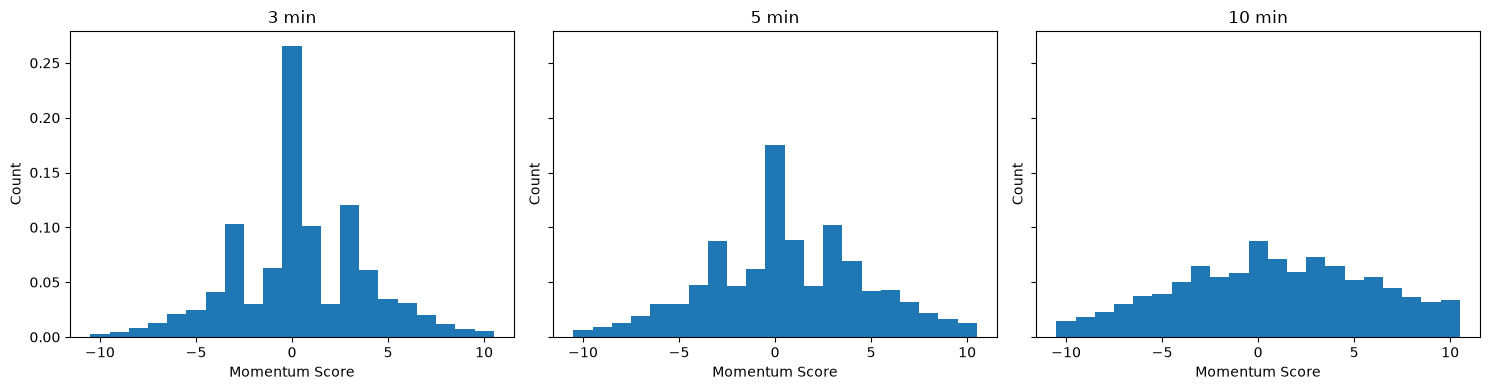

In [11]:
# Distribution

exp_a_df = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'event_side_annotations.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

datasets = {
    "3 min": win3_df,
    "5 min": exp_a_df,      # your original
    "10 min": win10_df
}

for ax, (title, df) in zip(axes, datasets.items()):
    ax.hist(df["momentum_score"], bins=np.arange(-10.5, 11.5, 1), density=True)
    ax.set_title(title)
    ax.set_xlabel("Momentum Score")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'window_histogram.png' , dpi=150)
plt.show()

In [12]:
short_summary = pd.DataFrame({
    "3 min": win3_df["momentum_score"].describe(),
    "5 min": exp_a_df["momentum_score"].describe(),
    "10 min": win10_df["momentum_score"].describe()
})

display(short_summary)

,3 min,5 min,10 min
count,254750.000000,162738.000000,83364.000000
mean,0.366385,0.574359,1.121119
std,3.642991,4.657549,6.764089
min,-27.000000,-27.000000,-34.000000
25%,-1.500000,-2.500000,-3.000000
50%,0.000000,0.000000,1.000000
75%,3.000000,3.000000,5.500000
max,27.000000,28.000000,41.000000


### 3.3 Train / Validation / Test split

In [13]:
a_train_ids = set(pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'train.csv')['id_odsp'].unique())
a_val_ids = set(pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'val.csv')['id_odsp'].unique())
a_test_ids = set(pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_a_prefix' / 'test.csv')['id_odsp'].unique())

datasets = {'exp_e_window3': win3_df, 'exp_e_window10': win10_df}

for subfolder, raw in datasets.items():
    out_dir = BASE_DIR / 'data' / 'processed' / 'exp_e_window_sens' / subfolder
    out_dir.mkdir(parents=True, exist_ok=True)

    train_df = raw[raw['id_odsp'].isin(a_train_ids)]
    val_df = raw[raw['id_odsp'].isin(a_val_ids)]
    test_df = raw[raw['id_odsp'].isin(a_test_ids)]

    train_df.to_csv(out_dir / 'train.csv', index=False)
    val_df.to_csv(out_dir / 'val.csv', index=False)
    test_df.to_csv(out_dir / 'test.csv', index=False)

    print(f"{subfolder}: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

exp_e_window3: train=178199, val=38204, test=38347
exp_e_window10: train=58348, val=12505, test=12511


### 3.4 Split Validation

In [14]:
assert (
    train_df["id_odsp"].nunique()
    + val_df["id_odsp"].nunique()
    + test_df["id_odsp"].nunique()
) == df["id_odsp"].nunique()

In [15]:
# No Overlap between splits

assert a_train_ids.isdisjoint(a_val_ids)
assert a_train_ids.isdisjoint(a_test_ids)
assert a_val_ids.isdisjoint(a_test_ids)

In [16]:
# Split contains complete matches

assert len(train_df) == raw[raw["id_odsp"].isin(a_train_ids)].shape[0]
assert len(val_df) == raw[raw["id_odsp"].isin(a_val_ids)].shape[0]
assert len(test_df) == raw[raw["id_odsp"].isin(a_test_ids)].shape[0]

## 4. Model Training

The DistilBERT model architecture, tokenizer, optimization strategy, and training hyperparameters were kept identical to those used in Experiment A. The only experimental variable was the temporal window used during dataset construction (3, 5, or 10 minutes). This controlled setup ensures that any observed differences in predictive performance can be attributed to the window size rather than changes in the model or training procedure.

Separate models were trained independently on the training sets generated for each window size and evaluated on their corresponding held-out test sets using the same train, validation, and test match partitions adopted throughout the previous experiments.

## 5. Experimental Results

This section compares the predictive performance of the DistilBERT model across the three temporal window sizes. All models were trained using identical architectures and hyperparameters, allowing the impact of window size on momentum forecasting performance to be evaluated in isolation.

### 5.1 Classification Report

The classification reports for each window size are presented below. Performance is reported on the held-out test set using identical evaluation metrics to the previous experiments.

In [ ]:
from IPython.display import Markdown, display

with open(REPORTS_PATH / 'exp_e_window3' / 'bert_momentum.txt', 'r') as f:
    window3_report = f.read()

display(Markdown('### Experiment E - Window Size: 3'))
print(window3_report)

### Experiment E - Window Size: 3

 DistilBERT - Test Set Evaluation
               precision    recall  f1-score   support

Home Dominant       0.99      0.98      0.99     12331
Away Dominant       0.98      0.98      0.98      9429
     Balanced       0.98      0.98      0.98     16587

     accuracy                           0.98     38347
    macro avg       0.98      0.98      0.98     38347
 weighted avg       0.98      0.98      0.98     38347



In [ ]:
with open(BASE_DIR / 'reports' / 'metrics' / 'exp_a_prefix' / 'bert_momentum.txt', 'r') as f:
    window5_report = f.read()

display(Markdown('### Experiment A - Window Size: 5'))
print(window5_report)

### Experiemnt A - Window Size: 5

 DistilBERT - Test Set Evaluation
               precision    recall  f1-score   support

Home Dominant       0.94      0.92      0.93      9492
Away Dominant       0.93      0.91      0.92      7095
     Balanced       0.85      0.90      0.87      7870

     accuracy                           0.91     24457
    macro avg       0.91      0.91      0.91     24457
 weighted avg       0.91      0.91      0.91     24457



In [ ]:
with open(REPORTS_PATH / 'exp_e_window10' / 'bert_momentum.txt', 'r') as f:
    window10_report = f.read()

display(Markdown('### Experiment E - Window Size: 10'))
print(window10_report)

### Experiment E - Window Size: 10

 DistilBERT - Test Set Evaluation
               precision    recall  f1-score   support

Home Dominant       0.84      0.72      0.77      5850
Away Dominant       0.73      0.72      0.73      4116
     Balanced       0.40      0.54      0.46      2545

     accuracy                           0.68     12511
    macro avg       0.66      0.66      0.65     12511
 weighted avg       0.71      0.68      0.69     12511



### 5.2 Training Dynamics

Figure compares the training and validation loss curves for the three window sizes. Since the model architecture and optimization strategy were unchanged, differences in convergence behaviour primarily reflect differences in the datasets generated by each temporal window.

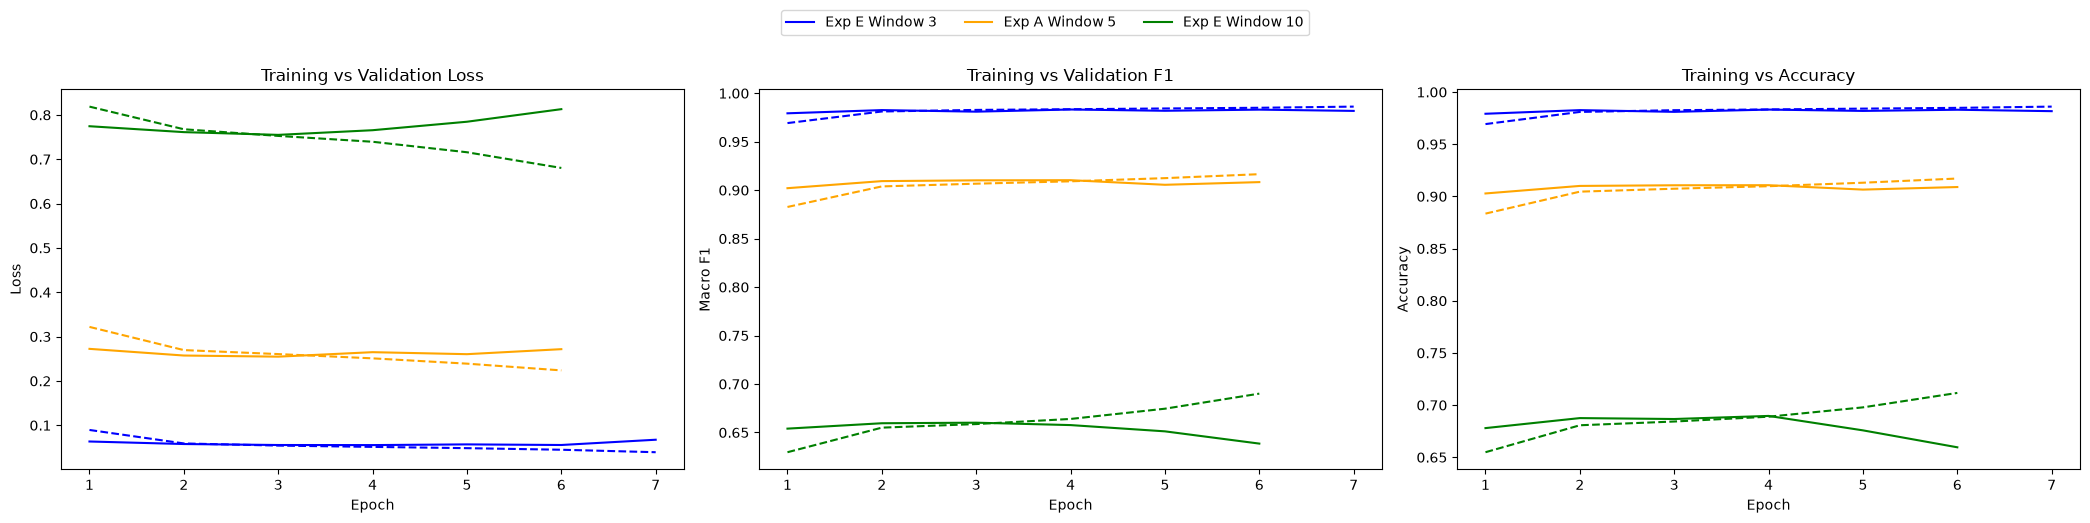

In [ ]:
win3_results = pd.read_csv(MODELS_PATH / 'exp_e_window3' / 'bert_momentum_results.csv')
win5_results = pd.read_csv(BASE_DIR / 'models' / 'exp_a_prefix' / 'distilbert_results.csv')
win10_results = pd.read_csv(MODELS_PATH / 'exp_e_window10' / 'bert_momentum_results.csv')


fig, axes = plt.subplots( 1, 3, figsize=(21,5))


# Loss curves
axes[0].plot(win3_results['epoch'], win3_results['train_loss'], label='Exp E Window 3', linestyle='--', color='blue')
axes[0].plot(win3_results['epoch'], win3_results['val_loss'], label='Exp E Window 3', color='blue')
axes[0].plot(win5_results['epoch'], win5_results['train_loss'], label='Exp A Window 5', linestyle='--',color='orange')
axes[0].plot(win5_results['epoch'], win5_results['val_loss'], label='Exp A Window 5', color='orange')
axes[0].plot(win10_results['epoch'], win10_results['train_loss'], label='Exp E Window 10', linestyle='--', color='green')
axes[0].plot(win10_results['epoch'], win10_results['val_loss'], label='Exp E Window 10', color='green')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

#F1 curves
axes[1].plot(win3_results['epoch'], win3_results['train_f1'], label='Exp E Window 3', linestyle='--', color='blue')
axes[1].plot(win3_results['epoch'], win3_results['val_f1'], label='Exp E Window 3', color='blue')
axes[1].plot(win5_results['epoch'], win5_results['train_f1'], label='Exp A Window 5', linestyle='--', color='orange')
axes[1].plot(win5_results['epoch'], win5_results['val_f1'], label='Exp A Window 5', color='orange')
axes[1].plot(win10_results['epoch'], win10_results['train_f1'], label='Exp E Window 10', linestyle='--', color='green')
axes[1].plot(win10_results['epoch'], win10_results['val_f1'], label='Exp E Window 10', color='green')
axes[1].set_title('Training vs Validation F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')

# Accuracy curves
axes[2].plot(win3_results['epoch'], win3_results['train_accuracy'], label='Exp E Window 3', linestyle='--', color='blue')
axes[2].plot(win3_results['epoch'], win3_results['val_accuracy'], label='Exp E Window 3', color='blue')
axes[2].plot(win5_results['epoch'], win5_results['train_accuracy'], label='Exp A Window 5', linestyle='--', color='orange')
axes[2].plot(win5_results['epoch'], win5_results['val_accuracy'], label='Exp A Window 5', color='orange')
axes[2].plot(win10_results['epoch'], win10_results['train_accuracy'], label='Exp E Window 10', linestyle='--', color='green')
axes[2].plot(win10_results['epoch'], win10_results['val_accuracy'], label='Exp E Window 10', color='green')
axes[2].set_title('Training vs Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # remove duplicate labels

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.05)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIGURE_PATH / 'exp_e_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Confusion Matrix Comparison

The normalized confusion matrices provide a class-wise comparison of prediction behaviour across the three temporal window sizes.

In [ ]:
# Load preds & labels

# Experiment E - Window Size 3
win3_preds = np.load(REPORTS_PATH/ 'exp_e_window3'/'bert_momentum_preds.npy')
win3_labels = np.load(REPORTS_PATH/'exp_e_window3'/'bert_momentum_labels.npy')

# Experiment A
win5_preds = np.load(BASE_DIR / 'reports' / 'metrics' / 'exp_a_prefix' / 'bert_momentum_preds.npy')
win5_labels = np.load(BASE_DIR / 'reports' / 'metrics' / 'exp_a_prefix' / 'bert_momentum_labels.npy')

# Experiment E - Window Size 10
win10_preds = np.load(REPORTS_PATH/ 'exp_e_window10'/'bert_momentum_preds.npy')
win10_labels = np.load(REPORTS_PATH/'exp_e_window10'/'bert_momentum_labels.npy')

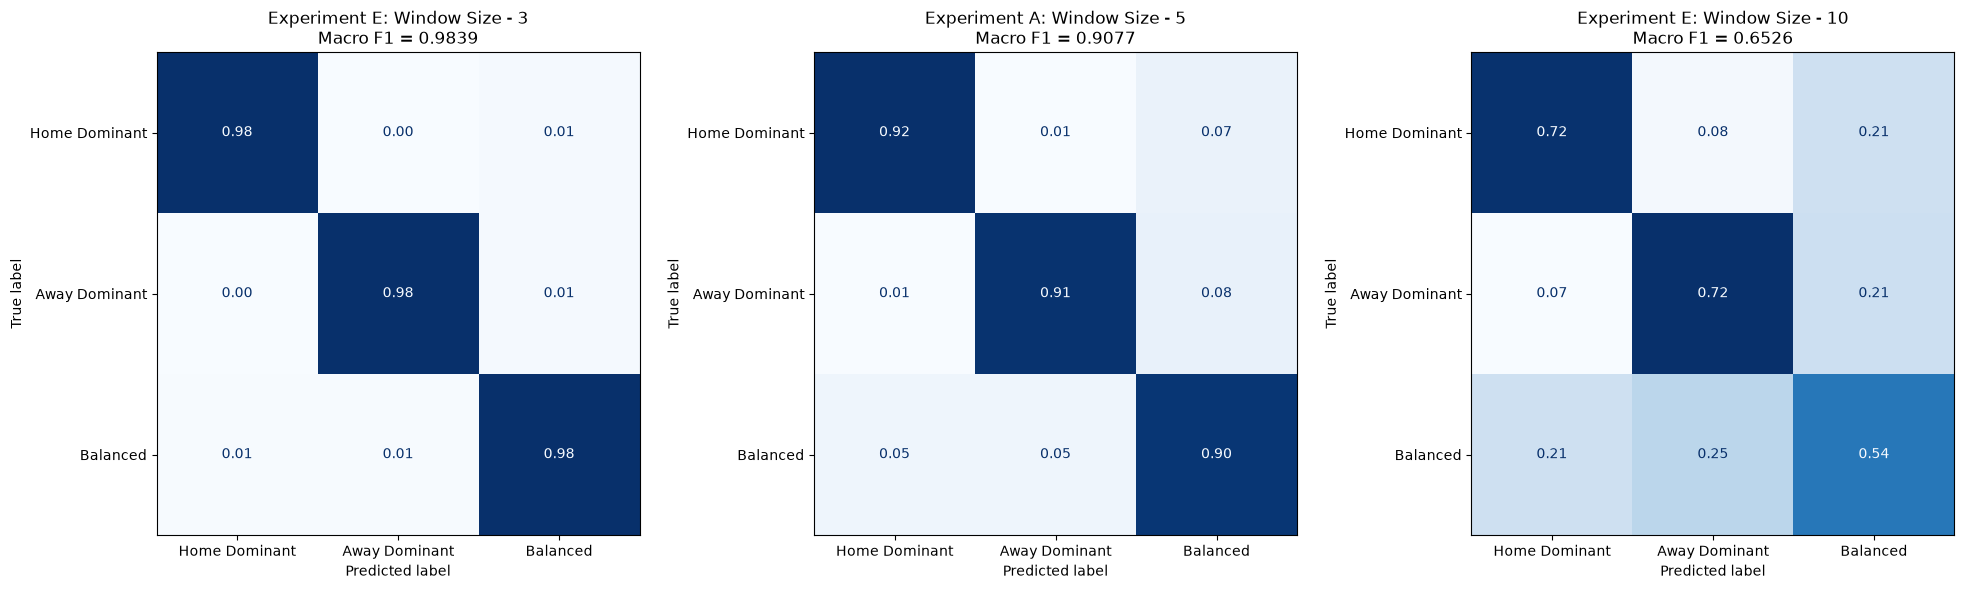

In [ ]:
win3_f1 = f1_score(win3_labels, win3_preds, average="macro")
win5_f1 = f1_score(win5_labels, win5_preds, average="macro")
win10_f1 = f1_score(win10_labels, win10_preds, average="macro")

fig, axes = plt.subplots(1, 3, figsize=(20,10))

ConfusionMatrixDisplay.from_predictions(
    win3_labels,
    win3_preds,
    display_labels=CLASS_NAMES,
    cmap="Blues",
    normalize='true',
    values_format=".2f",
    colorbar=False,
    ax=axes[0]
)


axes[0].set_title(f"Experiment E: Window Size - 3\nMacro F1 = {win3_f1:.4f}",fontsize=12,)

ConfusionMatrixDisplay.from_predictions(
    win5_labels,
    win5_preds,
    display_labels=CLASS_NAMES,
    cmap="Blues",
    normalize='true',
    values_format=".2f",
    colorbar=False,
    ax=axes[1]
)

axes[1].set_title(f"Experiment A: Window Size - 5\nMacro F1 = {win5_f1:.4f}",fontsize=12,)

ConfusionMatrixDisplay.from_predictions(
    win10_labels,
    win10_preds,
    display_labels=CLASS_NAMES,
    cmap="Blues",
    normalize='true',
    values_format=".2f",
    colorbar=False,
    ax=axes[2]
)

axes[2].set_title(f"Experiment E: Window Size - 10\nMacro F1 = {win10_f1:.4f}",fontsize=12,)

plt.tight_layout(pad=2)
plt.savefig(FIGURE_PATH / 'exp_e_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Overall Metric Comparison

Table summarizes the overall performance obtained for each window size using the held-out test set.

In [ ]:
report_win3 = load_report(REPORTS_PATH / 'exp_e_window3' / "bert_momentum_metrics.txt")
report_win5 = load_report(BASE_DIR / 'reports' / 'metrics' / 'exp_a_prefix' / 'bert_momentum_metrics.txt')
report_win10 = load_report(REPORTS_PATH / 'exp_e_window10' / 'bert_momentum_metrics.txt')

metrics = {
    "Accuracy": lambda r: r["accuracy"],
    "Macro Precision": lambda r: r["macro avg"]["precision"],
    "Macro Recall": lambda r: r["macro avg"]["recall"],
    "Macro F1": lambda r: r["macro avg"]["f1-score"],
    "Weighted F1": lambda r: r["weighted avg"]["f1-score"],
}

labels = ("Home Dominant", "Away Dominant", "Balanced")
for label in labels:
    metrics[f"{label} F1"] = lambda r, label=label: r[label]["f1-score"]

comparison = pd.DataFrame({
    "Metric": list(metrics.keys()),
    "Experiment A": [fn(report_win5) for fn in metrics.values()],
    "Experiment E: Win 3": [fn(report_win3) for fn in metrics.values()],
    "Experiment E: Win 10": [fn(report_win10) for fn in metrics.values()],
})

comparison["Δ Win 3"] = comparison["Experiment E: Win 3"] - comparison["Experiment A"]
comparison["Δ Win 10"] = comparison["Experiment E: Win 10"] - comparison["Experiment A"]

display(
    comparison.style
    .format({
        "Experiment A": "{:.4f}",
        "Experiment E: Win 3": "{:.4f}",
        "Experiment E: Win 10": "{:.4f}",
        "Δ Win 3": "{:+.4f}",
        "Δ Win 10": "{:+.4f}",
    })
    .background_gradient(
        subset=["Δ Win 3", "Δ Win 10"],
        cmap="RdYlGn",
        vmin=-comparison[["Δ Win 3", "Δ Win 10"]].abs().max().max(),
        vmax=comparison[["Δ Win 3", "Δ Win 10"]].abs().max().max(),
    )
    .hide(axis="index")
)


Metric,Experiment A,Experiment E: Win 3,Experiment E: Win 10,Δ Win 3,Δ Win 10
Accuracy,0.9086,0.9838,0.6823,+0.0752,-0.2263
Macro Precision,0.9081,0.9839,0.6560,+0.0758,-0.2521
Macro Recall,0.9078,0.9839,0.6597,+0.0760,-0.2482
Macro F1,0.9077,0.9839,0.6526,+0.0762,-0.2551
Weighted F1,0.9090,0.9838,0.6934,+0.0748,-0.2156
Home Dominant F1,0.9316,0.9862,0.7723,+0.0545,-0.1593
Away Dominant F1,0.9174,0.9830,0.7258,+0.0656,-0.1916
Balanced F1,0.8742,0.9825,0.4598,+0.1083,-0.4144


## 6. Dataset Analysis

### 6.1 Summary Statistics

The Table summarizes the characteristics of the datasets generated using each temporal window size. As the window size increases, fewer training samples are produced while each sample contains more events and longer textual descriptions. The table also reports the average absolute momentum score and class distribution for each dataset.

In [ ]:
train3 = win3_df[win3_df["id_odsp"].isin(a_train_ids)]
train5 = exp_a_df[exp_a_df["id_odsp"].isin(a_train_ids)]
train10 = win10_df[win10_df["id_odsp"].isin(a_train_ids)]

summary_df = pd.DataFrame({
    "Window Size": ["3 min", "5 min", "10 min"],
    "Train Samples": [
        len(train3),
        len(train5),
        len(train10)
    ],
    "Avg. Events / Window": [
        train3["text"].str.count(r"\[HOME_TEAM\]|\[AWAY_TEAM\]").mean(),
        train5["text"].str.count(r"\[HOME_TEAM\]|\[AWAY_TEAM\]").mean(),
        train10["text"].str.count(r"\[HOME_TEAM\]|\[AWAY_TEAM\]").mean()
    ],
    "Avg. Text Length": [
        train3["text"].str.split().str.len().mean(),
        train5["text"].str.split().str.len().mean(),
        train10["text"].str.split().str.len().mean()
    ],
    "Avg. Momentum Score": [
        train3["momentum_score"].mean(),
        train5["momentum_score"].mean(),
        train10["momentum_score"].mean()
    ],
    "Balanced (%)":[
        (train3["momentum_score"] > 0).mean() * 100,
        (train5["momentum_score"] > 0).mean() * 100,
        (train10["momentum_score"] > 0).mean() * 100
    ]
})

display(summary_df.style.format({
        "Train Samples": "{:,}",
        "Avg. Events / Window": "{:.2f}",
        "Avg. Text Length": "{:.2f}",
        "Avg. Momentum Score": "{:.2f}",
        "Balanced (%)": "{:.2f}"
}).set_properties(**{"text-align": "center"})
.hide(axis='index')
)

Window Size,Train Samples,Avg. Events / Window,Avg. Text Length,Avg. Momentum Score,Balanced (%)
3 min,"178,199",3.53,46.96,0.35,42.35
5 min,"113,914",5.53,73.52,0.55,47.62
10 min,"58,348",10.80,143.61,1.08,53.39


### Key Observations

- Increasing the temporal window reduced the number of available training samples.
- Larger windows contained progressively more events and longer textual descriptions.
- The average absolute momentum score increased with the window size due to the accumulation of additional weighted events.

### 6.2 Class Distributions

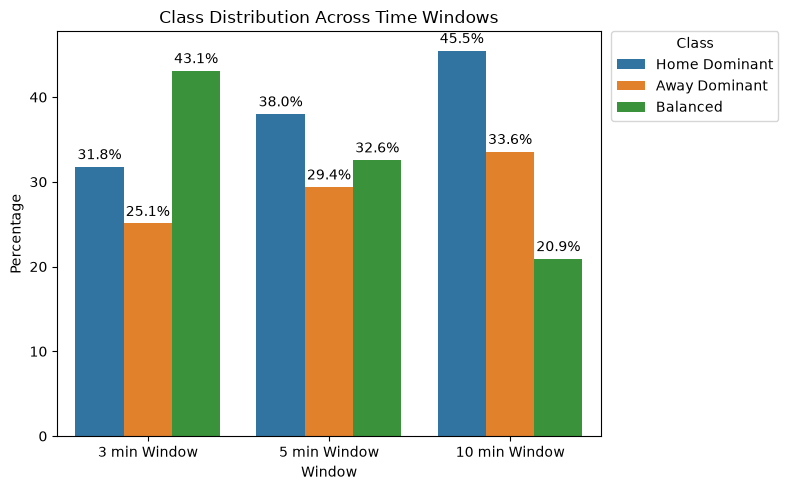

In [45]:
import seaborn as sns

plot_rows = []

datasets = {
    "3 min Window": train3,
    "5 min Window": train5,
    "10 min Window": train10
}

label_names = {
    0: "Home Dominant",
    1: "Away Dominant",
    2: "Balanced"
}

for window, df in datasets.items():
    pct = df["label"].value_counts(normalize=True).sort_index() * 100

    for label, value in pct.items():
        plot_rows.append({
            "Window": window,
            "Class": label_names[label],
            "Percentage": value
        })

plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=plot_df,
    x="Window",
    y="Percentage",
    hue="Class"
)

ax.legend(
    title="Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Class Distribution Across Time Windows")
plt.ylabel("Percentage")
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'experiment_e_class_distribution.png')
plt.show()

### Key Observations

- The proportion of Balanced windows decreased substantially as the temporal window increased.
- Longer windows produced a higher proportion of Home Dominant and Away Dominant samples.

### 6.3 Momentum Score Distribution by Window Size

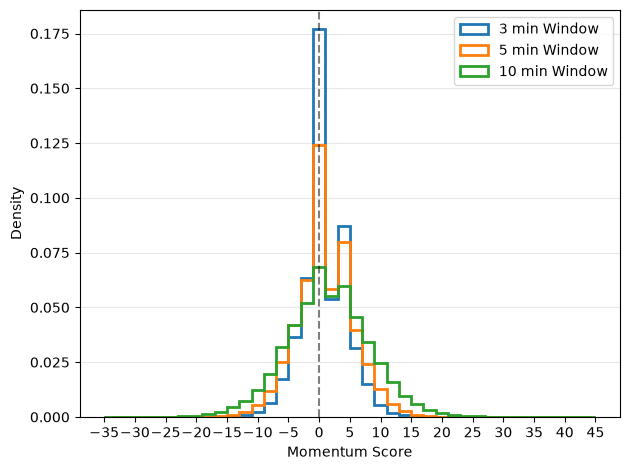

In [49]:
bins = np.arange(-35, 46, 2)

plt.hist(win3_df["momentum_score"],
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2,
        label="3 min Window")

plt.hist(exp_a_df["momentum_score"],
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2,
        label="5 min Window")

plt.hist(win10_df["momentum_score"],
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2,
        label="10 min Window")

plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.grid(axis='y', alpha=0.3)
plt.xticks(np.arange(-35, 46, 5))
plt.xlabel("Momentum Score")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURE_PATH/'momentum_score_distribution_hist.png')
plt.show()

### Key Observations

- Increasing the window size widened the momentum score distribution.
- The 3-minute window exhibited the strongest concentration around a momentum score of zero, while the 10-minute window produced substantially more extreme positive and negative momentum values.
- Larger temporal windows accumulated more weighted events within each sample, resulting in greater variability in momentum scores.

### 6.4 Task Complexity and Model Accuracy

The dataset characteristics in Section 6.1 show that the 3-minute window produces substantially sparser samples than the 5-minute or 10-minute configurations. To better understand the unusually high aggregate performance achieved by the 3-minute model, test-set accuracy was analysed as a function of (a) the number of sides appearing within a window and (b) the total number of events contained in the window.

In [50]:
test_df = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'exp_e_window_sens' / 'exp_e_window3' / 'test.csv')
preds = np.load(REPORTS_PATH / 'exp_e_window3' / 'bert_momentum_preds.npy')
labels = np.load(REPORTS_PATH / 'exp_e_window3' / 'bert_momentum_labels.npy')

assert len(preds) == len(test_df)

test_df['pred'] = preds
test_df['correct'] = (test_df['label'].values == preds)

test_df['has_home_tag'] = test_df['text'].str.contains(r'\[HOME_TEAM\]', regex=True)
test_df['has_away_tag'] = test_df['text'].str.contains(r'\[AWAY_TEAM\]', regex=True)
test_df['n_sides_present'] = test_df['has_home_tag'].astype(int) + test_df['has_away_tag'].astype(int)
test_df['n_events'] = test_df['text'].str.count(r'\[HOME_TEAM\]|\[AWAY_TEAM\]')

side_summary = test_df.groupby('n_sides_present').agg(n=('correct', 'size'), accuracy=('correct', 'mean'))
display(side_summary)

event_summary = test_df.groupby(pd.cut(test_df['n_events'], bins=[0,1,2,3,5,10,100]))['correct'].agg(['size', 'mean'])
display(event_summary)

,n,accuracy
n_sides_present,,
1,9314,0.999785
2,29033,0.978679


,size,mean
n_events,,
"(0, 1]",4959,0.999597
"(1, 2]",7683,1.000000
"(2, 3]",8056,0.999503
"(3, 5]",12025,0.993597
"(5, 10]",5575,0.906906
"(10, 100]",49,0.612245


- Windows mentioning only one side achieved 99.98% accuracy (n=9,314) — this task
  is close to trivial, since correctly identifying the momentum direction of a
  single-team window requires little more than reading the side tag.
- Windows mentioning both sides achieved 97.9% accuracy (n=29,033) — still higher
  than Experiment A's 91%, but a substantially smaller and more defensible margin
  than the aggregate 98.4% figure suggests.
- Accuracy declined sharply as event count increased: from ~99.6-100% for windows
  with 1-3 events down to 90.7% for 5-10 events and 61.2% for windows with more
  than 10 events. Given the 3-minute dataset is dominated by low-event-count
  windows (median 3 events), the aggregate score is weighted heavily toward these
  easier cases.

## 7. Discussion

This experiment investigated the sensitivity of football momentum forecasting to the temporal window used during momentum label generation. By evaluating 3-minute, 5-minute, and 10-minute windows under identical model architectures and training procedures, the effect of temporal aggregation could be isolated from other experimental factors.

### Why did the 3-minute window outperform?

The aggregate results suggest that the 3-minute window achieved the highest aggregate performance both the 5-minute and 10-minute configurations. However, the composition analysis in Section 6.4 shows this headline figure requires careful interpretation rather than a direct comparison to Experiment A.

The 3-minute dataset is dominated by short, sparse windows: 9,314 of 38,347 test windows (24%) mention only one side, and the median window contains just 3 events. On these single-sided windows, the model achieves 99.98% accuracy — a task that is close to trivial, since the side tag alone is nearly sufficient to determine the label. Accuracy also declines sharply as event count increases, from near-perfect on windows with 1-3 events to 61% on windows with more than 10 events. Because the 3-minute dataset contains disproportionately many low-event windows compared to the 5-minute dataset, its aggregate macro F1 (0.9839) is substantially inflated by these easier cases relative to Experiment A's more evenly-distributed task.

A fairer comparison restricts attention to windows where both sides are present, the closer analogue to a typical 5-minute window. On this subset, the 3-minute model achieves 97.9% accuracy, compared to Experiment A's 91%. This is still a real improvement, and is consistent with the hypothesis that shorter windows produce commentary more tightly coupled to a single, localized momentum state. However, the magnitude of this genuine improvement (roughly 7 points) is far smaller than the aggregate comparison implies, and the two figures should not be conflated.

### Relationship between dataset characteristics and model performance

The dataset analysis provides additional insight into the observed performance differences. Increasing the temporal window reduced the total number of available training samples while simultaneously increasing the average number of events, text length, and absolute momentum score within each window.

The momentum score distributions also became progressively wider as the window size increased, indicating that longer windows accumulated larger positive and negative momentum values. In addition, the proportion of Balanced samples decreased substantially for the 10-minute configuration, resulting in a more imbalanced dataset compared with the 3-minute and 5-minute windows.

These changes suggest that longer windows not only modify the class distribution but also alter the relationship between the commentary and the generated labels. The superior performance of the 3-minute configuration is therefore likely influenced by both the increased number of training examples and the stronger alignment between textual descriptions and localized momentum states.

### Limitations

As with the previous experiments, these results are based on a single training run for each model configuration and were not validated across multiple random seeds. Although the performance differences are substantial—particularly between the 3-minute and 10-minute windows, additional repeated experiments would provide greater confidence in the stability of the observed trends.

Furthermore, only three temporal window sizes were investigated while the momentum scoring scheme and classification thresholds remained unchanged. Exploring alternative weighting strategies, adaptive thresholds, or overlapping temporal windows may provide additional insight into the relationship between temporal aggregation and football momentum forecasting.

## 8. Conclusion

This experiment investigated the sensitivity of football momentum forecasting to the temporal window used during momentum label generation. Three window sizes (3, 5, and 10 minutes) were evaluated using the same DistilBERT architecture and training procedure to isolate the effect of temporal aggregation.

The 3-minute configuration achieved the highest aggregate predictive performance among the evaluated window sizes. However, further analysis showed that this improvement was influenced by changes in dataset composition, with shorter windows producing a larger proportion of sparse, low-event samples that were substantially easier to classify. Consequently, the observed performance gain should not be interpreted solely as evidence of a superior model.

These findings suggest that football momentum is better represented using shorter temporal windows, where the commentary remains closely aligned with the underlying momentum state. Longer windows aggregate multiple phases of play into a single training instance, making the relationship between the text and the assigned momentum label less consistent.

Overall, the experiment demonstrates that temporal window size is a critical design choice in football momentum forecasting, but that comparing aggregate metrics across window sizes can be misleading without accounting for how window size changes the composition and difficulty of the underlying task. The 3-minute configuration's aggregate score is substantially inflated by a large proportion of near-trivial, single-event windows; a fairer comparison restricted to harder, multi-event windows still favors the 3-minute configuration, but by a much smaller and more defensible margin (97.9% vs. 91% accuracy). Given this, window size should not be changed for deployment purposes based on the aggregate figure alone, the 5-minute configuration from Experiment A remains the safer, better-understood
choice, with window size sensitivity noted here as a promising direction for further controlled investigation (e.g., evaluating exclusively on multi-event windows across all three configurations) rather than a settled result.